💼 Employee Promotion Data Analysis Pipeline
✅ Successfully loaded data from _promote.csv
📊 Dataset Overview:
Shape: (100, 17)
Columns: ['Employee ID', 'Name', 'Date of Birth', 'Hire Date', 'Age', 'Years at Company', 'Role', 'Department', 'Email', 'Phone', 'Address', 'Gender', 'Salary', 'Previous Company', 'Degree Earned', 'Skills', 'Promoted']

First few rows:
   Employee ID              Name Date of Birth   Hire Date  Age  \
0         1000     Bethany Sloan    1973-10-31  2013-08-11   50   
1         1001        Dana Arias    1965-01-17  1987-06-28   58   
2         1002  Anthony Andersen    1964-12-14  2015-09-03   59   
3         1003     Linda Carlson    1994-05-24  2021-02-18   29   
4         1004   Catherine Jones    1980-08-30  2008-08-20   43   

   Years at Company                                          Role  \
0                10                       Chief Financial Officer   
1                36                  IT technical support officer   
2                 8  Produc

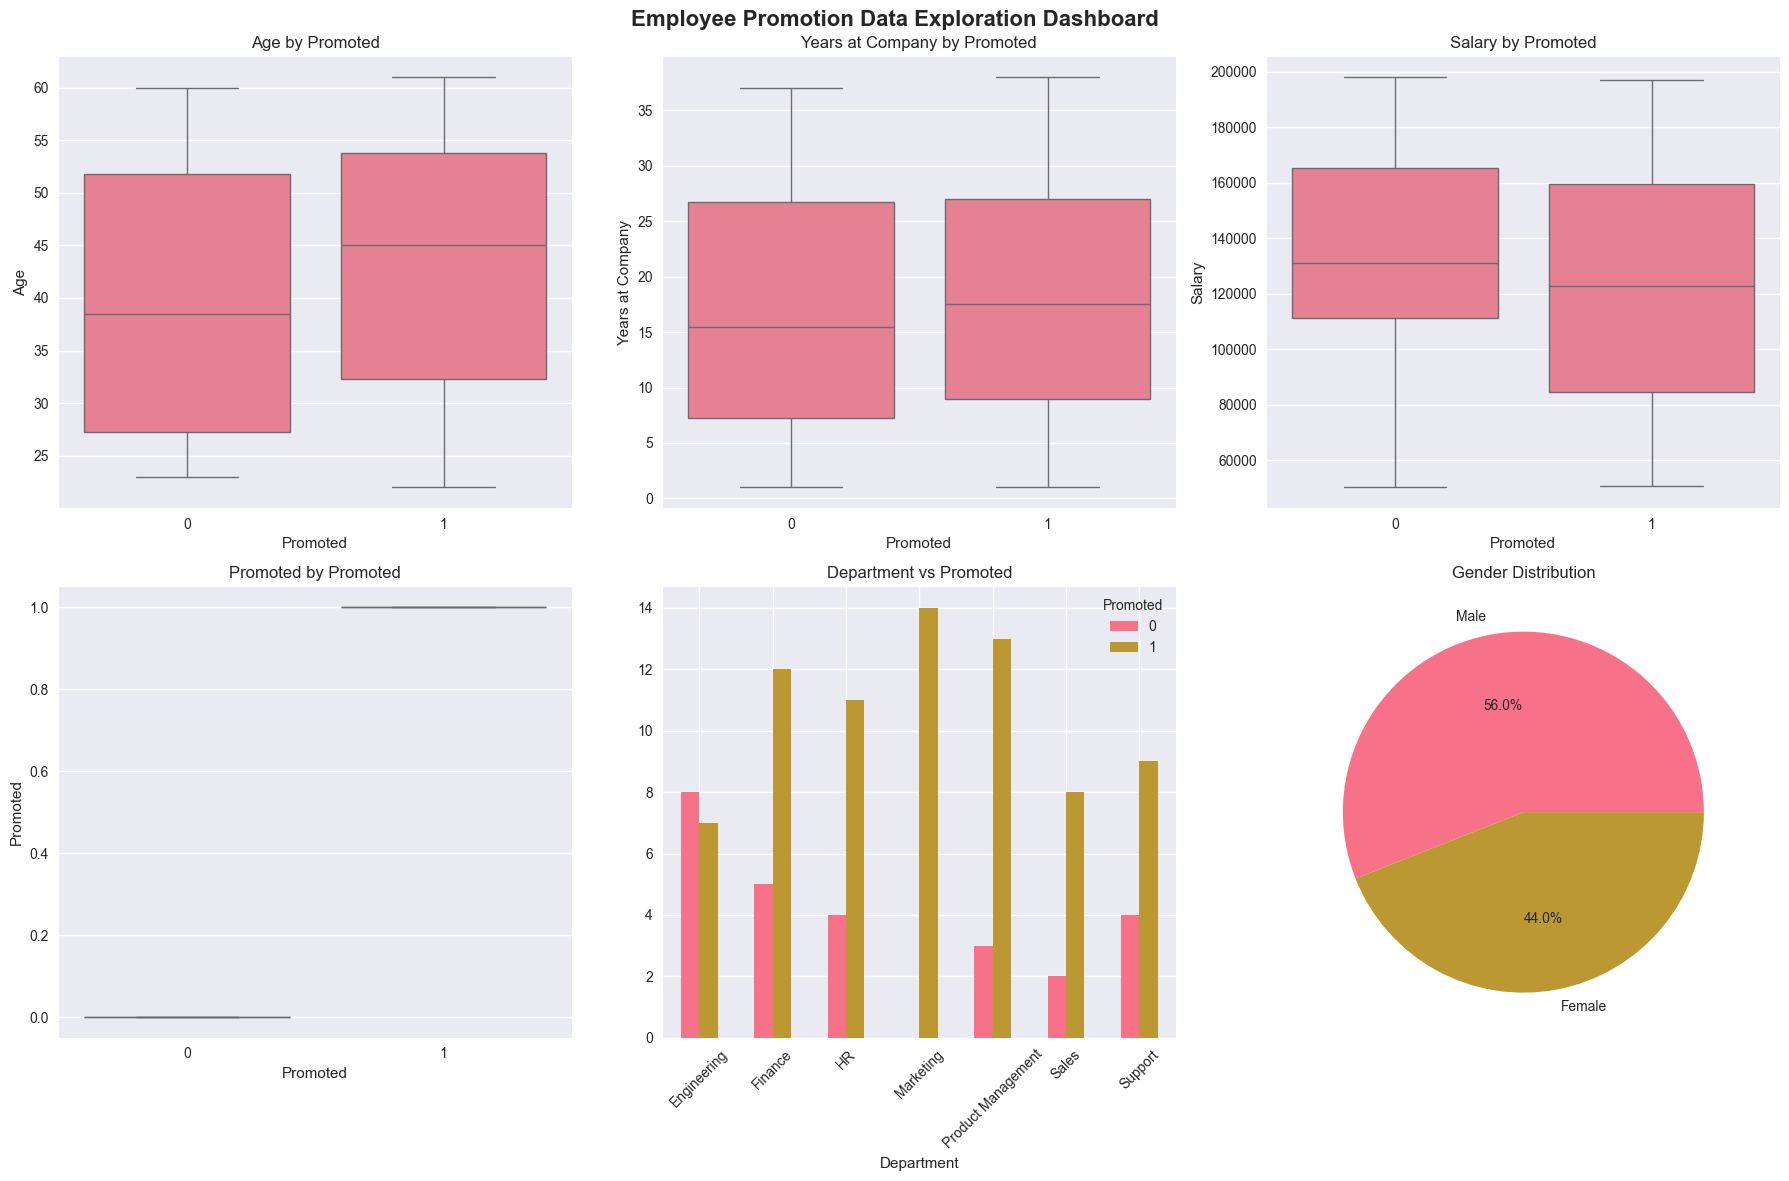


📈 Correlation Analysis
-------------------------
Correlations with promotion target:
Age                 0.130741
Years at Company    0.052060
Salary             -0.145695
Name: Promoted, dtype: float64


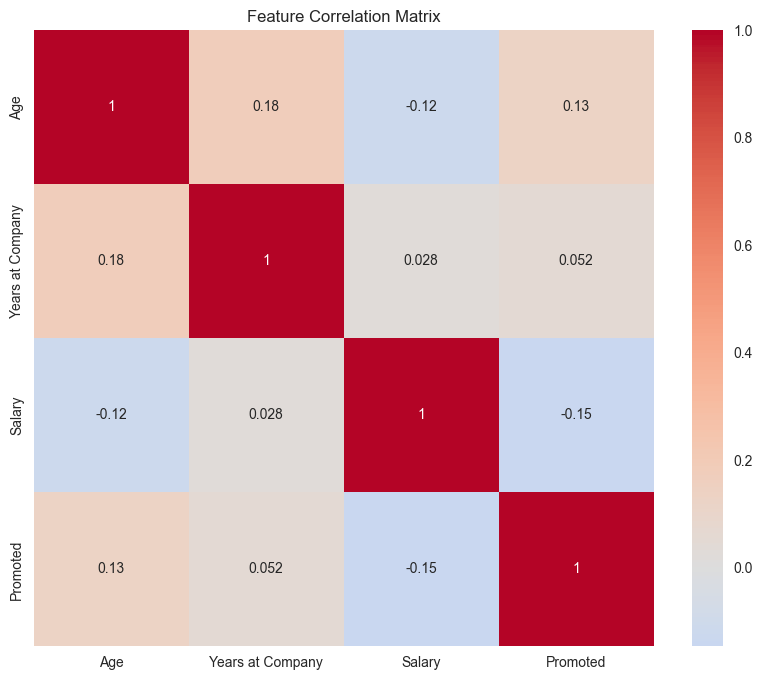


🚨 Data Leakage Risk Assessment
--------------------------------
  Employee ID: NO RISK - Random identifier
  Name: LOW RISK - Could introduce bias
  Date of Birth: NO RISK - Available before promotion decision
  Hire Date: NO RISK - Available before promotion decision
  Age: HIGH RISK - Data quality issues, can be calculated from Date of Birth
  Years at Company: HIGH RISK - Data quality issues, can be calculated from Hire Date
  Role: NO RISK - Current role skills/categories available before promotion
  Department: LOW RISK - Department transfer might coincide with promotion
  Email: NO RISK - Identifier
  Phone: NO RISK - Personal info
  Address: LOW RISK - Could introduce geographic bias
  Gender: LOW RISK - Could introduce bias but legally protected
  Salary: MEDIUM RISK - Salary increase often accompanies promotion
  Previous Company: NO RISK - Historical data
  Degree Earned: NO RISK - Educational background
  Skills: NO RISK - Skills available before promotion decision

⚠️ WARN

In [25]:
# Employee Promotion Data Analysis Pipeline - Adapted from Student Admissions
# Modular functions for reusable analysis across HR datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_and_inspect_data(filepath):
    """
    Load data and perform initial inspection
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Loaded dataframe
        dict: Basic info about the dataset
    """
    df = pd.read_csv(filepath)
    print(f"✅ Successfully loaded data from {filepath}")
    
    info = {
        'shape': df.shape,
        'columns': list(df.columns),
        'dtypes': df.dtypes.to_dict(),
        'memory_usage': df.memory_usage(deep=True).sum()
    }
    
    print("📊 Dataset Overview:")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print("\nFirst few rows:")
    print(df.head())
    
    return df, info

def auto_detect_column_types(df):
    """
    Automatically detect numerical, categorical, and identifier columns for HR data
    
    Args:
        df (pd.DataFrame): Input dataframe
        
    Returns:
        dict: Dictionary with column types
    """
    print(f"\n🔍 Auto-detecting Column Types")
    print("-" * 30)
    
    numerical_cols = []
    categorical_cols = []
    identifier_cols = []
    date_cols = []
    text_cols = []  # For Skills and Role columns
    
    for col in df.columns:
        # Skip obvious identifiers and personal info
        col_normalized = col.lower().replace(' ', '').replace('_', '')
        if any(keyword in col_normalized for keyword in ['id', 'name', 'email', 'phone', 'address']):
            identifier_cols.append(col)
        # Date columns
        elif 'date' in col_normalized or 'birth' in col_normalized:
            date_cols.append(col)
        # Skills and Role columns (comma-separated text)
        elif col in ['Skills', 'Role']:
            text_cols.append(col)
            print(f"  {col}: Detected as comma-separated categorical text")
        # Numerical columns
        elif df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
        # Categorical columns (strings with reasonable number of unique values)
        elif df[col].dtype == 'object':
            unique_count = df[col].nunique()
            if unique_count <= 50:  # Reasonable threshold for categories
                categorical_cols.append(col)
            else:
                identifier_cols.append(col)  # Too many unique values, likely an identifier
    
    column_types = {
        'numerical': numerical_cols,
        'categorical': categorical_cols,
        'identifiers': identifier_cols,
        'dates': date_cols,
        'text': text_cols
    }
    
    print("Detected column types:")
    print(f"Numerical: {numerical_cols}")
    print(f"Categorical: {categorical_cols}")
    print(f"Date columns: {date_cols}")
    print(f"Text columns (Skills/Role): {text_cols}")
    print(f"Identifiers: {identifier_cols}")
    
    return column_types

def assess_data_quality(df, numerical_cols=None, categorical_cols=None):
    """
    Assess data quality issues and anomalies for HR data
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical column names
        categorical_cols (list): List of categorical column names
        
    Returns:
        dict: Data quality assessment results
    """
    print(f"\n📋 Data Quality Assessment")
    print("-" * 30)
    
    # Basic checks
    duplicates = df.duplicated().sum()
    missing_values = df.isnull().sum()
    
    print(f"Duplicate rows: {duplicates}")
    if missing_values.sum() > 0:
        print(f"Missing values per column:")
        print(missing_values[missing_values > 0])
    else:
        print("No missing values found ✅")
    
    quality_issues = {
        'duplicates': duplicates,
        'missing_values': missing_values.to_dict(),
        'anomalies': {}
    }
    
    # Domain-specific anomaly checks for HR data
    if 'Age' in df.columns:
        age_high = (df['Age'] > 100).sum()
        age_low = (df['Age'] < 16).sum()
        quality_issues['anomalies']['Age_out_of_range'] = age_high + age_low
        if age_high > 0:
            print(f"Age > 100: {age_high} records")
        if age_low > 0:
            print(f"Age < 16: {age_low} records")
    
    if 'Salary' in df.columns:
        salary_negative = (df['Salary'] < 0).sum()
        salary_very_high = (df['Salary'] > 1000000).sum()
        quality_issues['anomalies']['Salary_issues'] = salary_negative + salary_very_high
        if salary_negative > 0:
            print(f"Negative salary: {salary_negative} records")
        if salary_very_high > 0:
            print(f"Salary > $1M: {salary_very_high} records")
    
    if 'Years at Company' in df.columns:
        years_negative = (df['Years at Company'] < 0).sum()
        years_excessive = (df['Years at Company'] > 60).sum()
        quality_issues['anomalies']['Years_at_Company_issues'] = years_negative + years_excessive
        if years_negative > 0:
            print(f"Negative years at company: {years_negative} records")
        if years_excessive > 0:
            print(f"Years at company > 60: {years_excessive} records")
    
    return quality_issues

def analyze_target_distribution(df, target_col):
    """
    Analyze the distribution of the target variable (promotion status)
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Target distribution statistics
    """
    print(f"\n🎯 Target Variable Analysis: {target_col}")
    print("-" * 35)
    
    target_counts = df[target_col].value_counts()
    print(f"Distribution:")
    print(target_counts)
    
    # Calculate promotion rate
    if target_col == 'Promoted' or '1' in target_counts.index or 1 in target_counts.index:
        promoted_count = target_counts.get(1, target_counts.get('1', 0))
        promotion_rate = promoted_count / len(df) * 100
        print(f"Promotion Rate: {promotion_rate:.1f}%")
        
        return {
            'counts': target_counts.to_dict(),
            'promotion_rate': promotion_rate
        }
    
    return {'counts': target_counts.to_dict()}

def create_exploratory_visualizations(df, target_col, numerical_cols, categorical_cols):
    """
    Create comprehensive exploratory visualizations for HR data
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        numerical_cols (list): List of numerical columns
        categorical_cols (list): List of categorical columns
    """
    print(f"\n🔍 Creating Exploratory Visualizations")
    print("-" * 40)
    
    # Calculate subplot dimensions
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Employee Promotion Data Exploration Dashboard', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    plot_idx = 0
    
    # Key numerical features vs target
    priority_numerical = ['Age', 'Years at Company', 'Salary']
    numerical_to_plot = [col for col in priority_numerical if col in df.columns] + \
                       [col for col in numerical_cols if col not in priority_numerical]
    
    for col in numerical_to_plot[:4]:  # Limit to first 4 numerical columns
        if plot_idx < 6 and col in df.columns:
            sns.boxplot(data=df, x=target_col, y=col, ax=axes[plot_idx])
            axes[plot_idx].set_title(f'{col} by {target_col}')
            plot_idx += 1
    
    # Key categorical features
    priority_categorical = ['Department', 'Gender', 'Degree Earned']
    categorical_to_plot = [col for col in priority_categorical if col in df.columns] + \
                         [col for col in categorical_cols if col not in priority_categorical]
    
    for col in categorical_to_plot[:2]:  # Limit to first 2 categorical columns
        if plot_idx < 6 and col in df.columns:
            unique_count = df[col].nunique()
            if unique_count <= 10:  # Only plot if reasonable number of categories
                if plot_idx == len(axes) - 1:  # Use pie chart for last plot
                    counts = df[col].value_counts()
                    axes[plot_idx].pie(counts.values, labels=counts.index, autopct='%1.1f%%')
                    axes[plot_idx].set_title(f'{col} Distribution')
                else:
                    pd.crosstab(df[col], df[target_col]).plot(kind='bar', ax=axes[plot_idx])
                    axes[plot_idx].set_title(f'{col} vs {target_col}')
                    axes[plot_idx].tick_params(axis='x', rotation=45)
                plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_feature_correlations(df, numerical_cols, target_col):
    """
    Analyze correlations between features and target for HR data
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical columns
        target_col (str): Name of target column
        
    Returns:
        pd.Series: Correlations with target variable
    """
    print(f"\n📈 Correlation Analysis")
    print("-" * 25)
    
    # Encode target if categorical
    df_corr = df.copy()
    if df[target_col].dtype == 'object':
        le = LabelEncoder()
        df_corr[f'{target_col}_encoded'] = le.fit_transform(df[target_col])
        target_encoded = f'{target_col}_encoded'
    else:
        target_encoded = target_col
    
    # Calculate correlations - only include numerical columns and target (avoid duplicates)
    correlation_cols = [col for col in numerical_cols if col in df.columns and col != target_col]
    
    # Add target column only if it's not already in the list
    if target_encoded not in correlation_cols:
        correlation_cols.append(target_encoded)
    
    corr_matrix = df_corr[correlation_cols].corr()
    
    # Get correlations with target and ensure it's a Series
    corr_with_target = corr_matrix[target_encoded]
    if isinstance(corr_with_target, pd.DataFrame):
        corr_with_target = corr_with_target.iloc[:, 0]  # Take first column if DataFrame
    
    # Drop the target's correlation with itself
    corr_with_target = corr_with_target.drop(labels=target_encoded)
    corr_with_target = corr_with_target.sort_values(ascending=False)
    
    print("Correlations with promotion target:")
    print(corr_with_target)
    
    # Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.show()
    
    return corr_with_target


def assess_data_leakage_risk(df, target_col):
    """
    Assess potential data leakage risks for HR promotion data
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Leakage risk assessment
    """
    print(f"\n🚨 Data Leakage Risk Assessment")
    print("-" * 32)
    
    # Define leakage risk rules for HR promotion data
    leakage_rules = {
        'Employee ID': 'NO RISK - Random identifier',
        'Name': 'LOW RISK - Could introduce bias',
        'Date of Birth': 'NO RISK - Available before promotion decision',
        'Hire Date': 'NO RISK - Available before promotion decision',
        'Age': 'HIGH RISK - Data quality issues, can be calculated from Date of Birth',
        'Years at Company': 'HIGH RISK - Data quality issues, can be calculated from Hire Date',
        'Role': 'NO RISK - Current role skills/categories available before promotion',
        'Department': 'LOW RISK - Department transfer might coincide with promotion',
        'Email': 'NO RISK - Identifier',
        'Phone': 'NO RISK - Personal info',
        'Address': 'LOW RISK - Could introduce geographic bias',
        'Gender': 'LOW RISK - Could introduce bias but legally protected',
        'Salary': 'MEDIUM RISK - Salary increase often accompanies promotion',
        'Previous Company': 'NO RISK - Historical data',
        'Degree Earned': 'NO RISK - Educational background',
        'Skills': 'NO RISK - Skills available before promotion decision'
    }
    
    assessment = {}
    for col in df.columns:
        if col != target_col:
            risk_level = leakage_rules.get(col, 'UNKNOWN RISK - Manual review needed')
            assessment[col] = risk_level
            print(f"  {col}: {risk_level}")
    
    # Specific data quality checks
    if 'Age' in df.columns and 'Date of Birth' in df.columns:
        print(f"\n⚠️ WARNING: Both Age and Date of Birth present - Age column has data quality issues and should be excluded")
        assessment['Age'] = 'HIGH RISK - Data quality issues, redundant with Date of Birth'
    
    if 'Years at Company' in df.columns and 'Hire Date' in df.columns:
        print(f"\n⚠️ WARNING: Both Years at Company and Hire Date present - Years at Company has data quality issues and should be excluded")
        assessment['Years at Company'] = 'HIGH RISK - Data quality issues, redundant with Hire Date'
    
    # Specific checks for HR data
    if 'Salary' in df.columns and target_col == 'Promoted':
        # Check if promoted employees have systematically higher salaries
        promoted_salary_mean = df[df[target_col] == 1]['Salary'].mean()
        not_promoted_salary_mean = df[df[target_col] == 0]['Salary'].mean()
        salary_diff_ratio = promoted_salary_mean / not_promoted_salary_mean if not_promoted_salary_mean > 0 else 0
        
        if salary_diff_ratio > 1.5:
            print(f"\n⚠️ WARNING: Promoted employees have {salary_diff_ratio:.1f}x higher average salary - potential leakage!")
            assessment['salary_leakage_risk'] = 'HIGH'
        else:
            assessment['salary_leakage_risk'] = 'LOW'
    
    assessment['critical_leakage_detected'] = False
    
    return assessment

def select_safe_features(df, leakage_assessment, column_types):
    """
    Select features that are safe to use (low leakage risk and not identifiers)
    
    Args:
        df (pd.DataFrame): Input dataframe
        leakage_assessment (dict): Output from assess_data_leakage_risk
        column_types (dict): Output from auto_detect_column_types
        
    Returns:
        list: List of safe feature names
    """
    safe_features = []
    
    # Get identifier columns to exclude
    identifier_cols = column_types.get('identifiers', [])
    text_cols = column_types.get('text', [])
    
    for feature, risk in leakage_assessment.items():
        if feature not in ['critical_leakage_detected', 'salary_leakage_risk']:
            # Only include NO RISK and LOW RISK features, exclude HIGH RISK and MEDIUM RISK
            if 'NO RISK' in risk or 'LOW RISK' in risk:
                if feature in df.columns and feature not in identifier_cols:
                    safe_features.append(feature)
            elif 'HIGH RISK' in risk:
                print(f"⚠️ Excluding {feature} due to HIGH RISK: {risk}")
    
    # Add text columns (Skills, Role) to safe features since they contain useful categorical info
    for col in text_cols:
        if col not in safe_features:
            safe_features.append(col)
            print(f"✅ Including {col} as text feature for processing")
    
    print(f"\n✅ Selected {len(safe_features)} safe features (excluding {len(identifier_cols)} identifiers):")
    print(f"Excluded identifiers: {identifier_cols}")
    print(f"Safe features: {safe_features}")
    
    return safe_features

def preprocess_text_features(df, text_cols):
    """
    Preprocess text features like Skills and Role that contain comma-separated values
    
    Args:
        df (pd.DataFrame): Input dataframe
        text_cols (list): List of text column names
        
    Returns:
        pd.DataFrame: DataFrame with processed text features
    """
    df_processed = df.copy()
    
    for col in text_cols:
        if col in df.columns:
            print(f"Processing {col} column...")
            
            # Split comma-separated values and create binary features for top categories
            all_values = []
            for row in df[col].dropna():
                if isinstance(row, str):
                    values = [v.strip() for v in row.split(',')]
                    all_values.extend(values)
            
            # Get top 10 most common values to avoid too many features
            from collections import Counter
            top_values = Counter(all_values).most_common(10)
            
            # Create binary features for top values
            for value, count in top_values:
                feature_name = f"{col}_{value.replace(' ', '_').replace('/', '_')}"
                df_processed[feature_name] = df[col].fillna('').str.contains(value, case=False, na=False).astype(int)
                print(f"  Created feature: {feature_name} (appears {count} times)")
            
            # Drop original text column
            df_processed = df_processed.drop(columns=[col])
    
    return df_processed

def make_classification_pipeline():
    """
    Create a classification pipeline with preprocessing for HR data
    
    Returns:
        Pipeline: Scikit-learn pipeline for classification
    """
    # Numerical preprocessing
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical preprocessing
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    # Combined preprocessor
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, lambda X: X.select_dtypes(include=[np.number]).columns.tolist()),
        ('cat', cat_pipeline, lambda X: X.select_dtypes(include=['object']).columns.tolist())
    ])
    
    # Complete pipeline with XGBoost
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=100, 
            random_state=42, 
            eval_metric='logloss',
            verbosity=0
        ))
    ])
    
    return pipeline

def tune_hyperparameters(X_train, y_train):
    """
    Perform hyperparameter tuning on XGBoost using GridSearchCV with 5-fold cross-validation
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (array-like): Training target
        
    Returns:
        tuple: (best_pipeline, best_params, cv_results)
    """
    print(f"\n🔧 Hyperparameter Tuning for XGBoost")
    print("-" * 35)
    
    # Create base pipeline
    base_pipeline = make_classification_pipeline()
    
    # Define parameter grid for XGBoost
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 6, 9],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
    
    # Perform grid search with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    print("Starting hyperparameter tuning...")
    print(f"Testing {len(param_grid['classifier__n_estimators']) * len(param_grid['classifier__max_depth']) * len(param_grid['classifier__learning_rate']) * len(param_grid['classifier__subsample']) * len(param_grid['classifier__colsample_bytree'])} parameter combinations")
    
    grid_search.fit(X_train, y_train)
    
    print(f"✅ Hyperparameter tuning complete!")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.cv_results_

def train_and_evaluate_models(df, feature_cols, target_col, tune_hyperparams=False):
    """
    Train and evaluate multiple classification models for promotion prediction
    
    Args:
        df (pd.DataFrame): Input dataframe
        feature_cols (list): List of feature column names
        target_col (str): Name of target column
        tune_hyperparams (bool): Whether to perform hyperparameter tuning on XGBoost
        
    Returns:
        dict: Model results and metrics
    """
    print(f"\n🤖 Training and Evaluating Promotion Prediction Models")
    print("-" * 50)
    
    # Identify text columns in feature_cols
    text_cols = [col for col in feature_cols if col in ['Skills', 'Role']]
    
    # Preprocess text features if any exist
    if text_cols:
        print(f"Preprocessing text features: {text_cols}")
        df_processed = preprocess_text_features(df, text_cols)
        
        # Update feature_cols to exclude original text columns and include new binary features
        feature_cols = [col for col in feature_cols if col not in text_cols]
        new_text_features = [col for col in df_processed.columns if any(col.startswith(f"{text_col}_") for text_col in text_cols)]
        feature_cols.extend(new_text_features)
        
        print(f"Added {len(new_text_features)} new text-based features")
    else:
        df_processed = df.copy()
    
    # Prepare data
    X = df_processed[feature_cols].copy()
    
    # Clean target variable - remove any NaN values
    target_data = df_processed[target_col].dropna()
    valid_indices = target_data.index
    X = X.loc[valid_indices]
    
    # Ensure target is binary
    if target_data.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(target_data)
        target_classes = ['Not Promoted', 'Promoted']
    else:
        y = target_data.values
        target_classes = ['Not Promoted', 'Promoted']
    
    print(f"Using {len(X)} samples after cleaning")
    print(f"Final feature count: {len(feature_cols)}")
    print(f"Target classes: {target_classes}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Define models
    models = {
        'Logistic Regression': Pipeline([
            ('preprocessor', make_classification_pipeline().named_steps['preprocessor']),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ])
    }
    
    # Add XGBoost model (tuned or default)
    if tune_hyperparams:
        print("Training XGBoost with hyperparameter tuning...")
        tuned_xgb, best_params, cv_results = tune_hyperparameters(X_train, y_train)
        models['XGBoost (Tuned)'] = tuned_xgb
    else:
        models['XGBoost'] = make_classification_pipeline()
    
    results = {}
    
    for name, pipeline in models.items():
        print(f"\nTraining {name}...")
        
        # Skip fitting for tuned XGBoost as it's already fitted
        if name == 'XGBoost (Tuned)':
            # Pipeline is already fitted from hyperparameter tuning
            pass
        else:
            # Train model
            pipeline.fit(X_train, y_train)
        
        # Predictions
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if len(np.unique(y)) == 2 else None
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
        
        results[name] = {
            'pipeline': pipeline,
            'accuracy': accuracy,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"Accuracy: {accuracy:.3f}")
        if auc_score:
            print(f"AUC Score: {auc_score:.3f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=target_classes))
    
    return results

def extract_feature_importance(model_results, feature_cols):
    """
    Extract and display feature importance from trained models
    
    Args:
        model_results (dict): Results from train_and_evaluate_models
        feature_cols (list): List of feature column names
        
    Returns:
        pd.DataFrame: Feature importance scores
    """
    print(f"\n🎯 Feature Importance Analysis")
    print("-" * 30)
    
    # Get XGBoost model (tuned or default)
    target_pipeline = None
    for name, results in model_results.items():
        if 'XGBoost' in name:
            target_pipeline = results['pipeline']
            break
    
    if target_pipeline is None:
        print("No XGBoost model found for feature importance extraction")
        return None
    
    # Extract feature names after preprocessing
    preprocessor = target_pipeline.named_steps['preprocessor']
    classifier = target_pipeline.named_steps['classifier']
    
    # Get feature names (this is tricky with ColumnTransformer)
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        # Fallback: use original feature names (not ideal but works)
        feature_names = feature_cols
    
    # Get importance scores
    if hasattr(classifier, 'feature_importances_'):
        importance_scores = classifier.feature_importances_
        
        # Create DataFrame
        n_features = min(len(feature_names), len(importance_scores))
        importance_df = pd.DataFrame({
            'feature': feature_names[:n_features],
            'importance': importance_scores[:n_features]
        }).sort_values('importance', ascending=False)
        
        print("Top feature importances for promotion prediction:")
        print(importance_df.head(10))
        
        return importance_df
    
    return None

def calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment):
    """
    Calculate an overall pipeline readiness score for HR promotion model
    
    Args:
        quality_issues (dict): Data quality assessment results
        model_results (dict): Model evaluation results
        leakage_assessment (dict): Leakage risk assessment
        
    Returns:
        dict: Readiness scores and overall assessment
    """
    print(f"\n💡 HR Pipeline Readiness Assessment")
    print("-" * 35)
    
    # Data quality score (0-100)
    quality_score = 100
    if quality_issues['duplicates'] > 0:
        quality_score -= 10
    
    missing_penalty = sum(1 for count in quality_issues['missing_values'].values() if count > 0)
    quality_score -= min(missing_penalty * 5, 30)
    
    anomaly_penalty = sum(quality_issues['anomalies'].values())
    quality_score -= min(anomaly_penalty, 30)
    
    quality_score = max(0, quality_score)
    
    # Model performance score (0-100)
    if model_results:
        best_auc = max([r.get('auc_score', 0) or 0 for r in model_results.values()])
        best_accuracy = max([r.get('accuracy', 0) for r in model_results.values()])
        performance_score = max(best_auc, best_accuracy) * 100
    else:
        performance_score = 0
    
    # Leakage risk score (0-100)
    high_risk_count = sum(1 for risk in leakage_assessment.values() 
                         if isinstance(risk, str) and 'HIGH RISK' in risk)
    medium_risk_count = sum(1 for risk in leakage_assessment.values() 
                           if isinstance(risk, str) and 'MEDIUM RISK' in risk)
    
    leakage_score = 100 - (high_risk_count * 30) - (medium_risk_count * 15)
    leakage_score = max(0, leakage_score)
    
    # Overall score
    overall_score = (quality_score + performance_score + leakage_score) / 3
    
    scores = {
        'data_quality': quality_score,
        'model_performance': performance_score,
        'leakage_risk': leakage_score,
        'overall': overall_score
    }
    
    print(f"Data Quality Score: {quality_score:.1f}/100")
    print(f"Model Performance Score: {performance_score:.1f}/100")
    print(f"Leakage Risk Score: {leakage_score:.1f}/100")
    print(f"Overall Pipeline Readiness: {overall_score:.1f}/100")
    
    return scores

def generate_summary_findings(df, scores, model_results, feature_importance):
    """
    Generate summary findings for the HR promotion analysis
    
    Args:
        df (pd.DataFrame): Input dataframe
        scores (dict): Pipeline readiness scores
        model_results (dict): Model evaluation results
        feature_importance (pd.DataFrame): Feature importance results
        
    Returns:
        list: Summary findings
    """
    findings = []
    
    findings.append(f"Dataset contains {len(df)} employee records with {len(df.columns)} features")
    
    if 'Promoted' in df.columns:
        promotion_rate = df['Promoted'].mean() * 100
        findings.append(f"Current promotion rate: {promotion_rate:.1f}%")
    
    findings.append(f"Overall pipeline readiness score: {scores['overall']:.1f}/100")
    
    if model_results:
        best_model = max(model_results.items(), key=lambda x: x[1].get('auc_score', 0) or x[1].get('accuracy', 0))
        best_score = best_model[1].get('auc_score') or best_model[1].get('accuracy')
        findings.append(f"Best model ({best_model[0]}) score: {best_score:.3f}")
    
    if feature_importance is not None and len(feature_importance) > 0:
        top_features = feature_importance.head(3)['feature'].tolist()
        findings.append(f"Top predictive features: {', '.join(top_features)}")
    
    return findings

def run_full_pipeline(filepath, target_col='Promoted', tune_hyperparams=False):
    """
    Run the complete HR promotion analysis pipeline
    
    Args:
        filepath (str): Path to the CSV file
        target_col (str): Name of the target column
        tune_hyperparams (bool): Whether to perform hyperparameter tuning on XGBoost
        
    Returns:
        dict: Complete analysis results
    """
    print("💼 Employee Promotion Data Analysis Pipeline")
    print("=" * 50)
    
    # 1. Load and inspect data
    df, basic_info = load_and_inspect_data(filepath)
    
    # 2. Auto-detect column types
    column_types = auto_detect_column_types(df)
    
    # 3. Assess data quality
    quality_issues = assess_data_quality(df, column_types['numerical'], column_types['categorical'])
    
    # 4. Analyze target distribution
    target_stats = analyze_target_distribution(df, target_col)
    
    # 5. Create visualizations
    create_exploratory_visualizations(df, target_col, column_types['numerical'], column_types['categorical'])
    
    # 6. Analyze correlations
    correlations = analyze_feature_correlations(df, column_types['numerical'], target_col)
    
    # 7. Assess leakage risk
    leakage_assessment = assess_data_leakage_risk(df, target_col)
    
    # 8. Select safe features
    safe_features = select_safe_features(df, leakage_assessment, column_types)
    
    # 9. Train and evaluate models
    model_results = train_and_evaluate_models(df, safe_features, target_col, tune_hyperparams)
    
    # 10. Extract feature importance
    feature_importance = extract_feature_importance(model_results, safe_features)
    
    # 11. Calculate readiness scores
    scores = calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment)
    
    # 12. Generate summary
    findings = generate_summary_findings(df, scores, model_results, feature_importance)
    
    print(f"\n📝 Key Findings Summary")
    print("-" * 25)
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")
    
    print(f"\n✅ HR Pipeline analysis complete!")
    
    return {
        'dataframe': df,
        'basic_info': basic_info,
        'column_types': column_types,
        'quality_issues': quality_issues,
        'target_stats': target_stats,
        'correlations': correlations,
        'leakage_assessment': leakage_assessment,
        'safe_features': safe_features,
        'model_results': model_results,
        'feature_importance': feature_importance,
        'scores': scores,
        'findings': findings
    }

# Example usage:
if __name__ == "__main__":
    # Run the complete pipeline without hyperparameter tuning
    results = run_full_pipeline("_promote.csv")
    
    # Or run with hyperparameter tuning (takes longer)
    # results = run_full_pipeline("promotion_data.csv", tune_hyperparams=True)
    
    # Access specific results
    print(f"\nSafe features to use: {results['safe_features']}")
    print(f"Overall readiness score: {results['scores']['overall']:.1f}")
    
    # Additional HR-specific insights
    if 'Promoted' in results['dataframe'].columns:
        df = results['dataframe']
        print(f"\nHR Insights:")
        print(f"- Total employees: {len(df)}")
        print(f"- Promotion rate: {df['Promoted'].mean()*100:.1f}%")
        
        if 'Department' in df.columns:
            dept_promotion = df.groupby('Department')['Promoted'].agg(['count', 'mean'])
            dept_promotion.columns = ['Total_Employees', 'Promotion_Rate']
            dept_promotion['Promotion_Rate'] *= 100
            print(f"\nPromotion rates by department:")
            print(dept_promotion.sort_values('Promotion_Rate', ascending=False))
        
        if 'Years at Company' in df.columns:
            tenure_groups = pd.cut(df['Years at Company'], 
                                 bins=[0, 2, 5, 10, 20, 100], 
                                 labels=['0-2 years', '3-5 years', '6-10 years', '11-20 years', '20+ years'])
            tenure_promotion = df.groupby(tenure_groups)['Promoted'].agg(['count', 'mean'])
            tenure_promotion.columns = ['Total_Employees', 'Promotion_Rate']
            tenure_promotion['Promotion_Rate'] *= 100
            print(f"\nPromotion rates by tenure:")
            print(tenure_promotion)
